# LIBRARY

In [47]:
import numpy as np
import pandas as pd
import gzip 
import pickle 
from collections import Counter
import matplotlib.pyplot as plt
import gzip
import pickle
import sys
import numpy as np
import warnings
import pandas as pd
from scipy.stats import levene
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.preprocessing import RobustScaler
from statsmodels.tsa.seasonal import STL
from statsmodels.tools.sm_exceptions import InterpolationWarning

warnings.simplefilter("ignore", InterpolationWarning)
warnings.simplefilter("ignore", UserWarning)



# DATAFRAMES

In [6]:
with gzip.open("../1.DATASET/CMI_timeseries_dataset.pkl.gz", "rb") as f:
	 CMI_timeseries_dataset = pickle.load(f)

In [7]:
# Check how many subjects/time series
print(f"Number of time series: {len(CMI_timeseries_dataset)}")

Number of time series: 4437


## FIRST ANALYSES

### COLUMNS

In [8]:
df = CMI_timeseries_dataset[0].copy()

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   X                    200 non-null    float32
 1   Y                    200 non-null    float32
 2   Z                    200 non-null    float32
 3   enmo                 200 non-null    float32
 4   anglez               200 non-null    float32
 5   non-wear_flag        200 non-null    float32
 6   light                200 non-null    float32
 7   battery_voltage      200 non-null    float32
 8   weekday              200 non-null    float64
 9   quarter              200 non-null    float64
 10  relative_date_PCIAT  200 non-null    float32
 11  id                   200 non-null    int64  
 12  sii_binary           200 non-null    int64  
dtypes: float32(9), float64(2), int64(2)
memory usage: 13.4 KB


### CLASS BALANCE

In [10]:
sii_distribution = [df['sii_binary'].iloc[0] for df in CMI_timeseries_dataset]
print(f"Class distribution: {sum(sii_distribution)} problematic, {len(sii_distribution)-sum(sii_distribution)} non-problematic")

Class distribution: 1480 problematic, 2957 non-problematic


### NULL VALUES

In [11]:
total_nulls = sum(df.isna().sum().sum() for df in CMI_timeseries_dataset)

if total_nulls == 0:
    print("No null values found in any DataFrame!")
else:
    print(f"Found {total_nulls} total null values")

No null values found in any DataFrame!


### UNIQUE VALUES

In [12]:
# attributes 
categorical_like = ['weekday', 'quarter', 'sii_binary', 'id', 'non-wear_flag']
continuous_like = ['X', 'Y', 'Z', 'enmo', 'anglez', 'light', 'battery_voltage', 'relative_date_PCIAT']

In [13]:
for col in categorical_like:
    all_values = sorted(set().union(*(df[col].unique() for df in CMI_timeseries_dataset)))
    print(f"\n{col}:\n   Unique values: {all_values}")


weekday:
   Unique values: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]

quarter:
   Unique values: [1.0, 2.0, 3.0, 4.0]

sii_binary:
   Unique values: [0, 1]

id:
   Unique values: [3, 25, 48, 51, 52, 63, 68, 82, 85, 90, 116, 118, 121, 129, 130, 132, 133, 134, 135, 140, 142, 150, 164, 167, 178, 179, 198, 200, 201, 206, 210, 214, 219, 220, 230, 231, 235, 239, 257, 270, 276, 277, 282, 284, 287, 300, 302, 310, 325, 339, 341, 347, 348, 354, 355, 367, 379, 380, 381, 382, 399, 407, 421, 428, 434, 459, 463, 465, 480, 503, 511, 514, 516, 520, 522, 523, 531, 537, 555, 558, 560, 566, 574, 575, 580, 599, 601, 606, 613, 633, 634, 642, 654, 657, 668, 670, 675, 681, 691, 692, 699, 706, 714, 717, 723, 732, 734, 735, 736, 739, 745, 749, 755, 764, 777, 783, 787, 789, 795, 797, 799, 828, 833, 835, 836, 839, 847, 851, 858, 861, 864, 881, 883, 884, 893, 894, 901, 910, 924, 929, 937, 941, 944, 956, 959, 969, 974, 975, 978, 981, 989, 996, 1008, 1011, 1014, 1017, 1024, 1027, 1028, 1035, 1044, 1050, 1054, 1056, 1069

In [14]:
for col in continuous_like:
    min_val, max_val = float('inf'), float('-inf')
    for df in CMI_timeseries_dataset:
        min_val, max_val = min(min_val, df[col].min()), max(max_val, df[col].max())
    print(f"\n{col}:\n   Range: [{min_val:.4f}, {max_val:.4f}]")


X:
   Range: [-8.0221, 1.3605]

Y:
   Range: [-2.0841, 1.5521]

Z:
   Range: [-1.0424, 8.0189]

enmo:
   Range: [0.0000, 7.0335]

anglez:
   Range: [-89.9032, 89.7458]

light:
   Range: [0.0000, 2594.6221]

battery_voltage:
   Range: [3099.0833, 6000.0000]

relative_date_PCIAT:
   Range: [-102.0000, 495.0000]


In [15]:
all_ids = [df['id'].iloc[0] for df in CMI_timeseries_dataset]
id_counts = Counter(all_ids)

In [16]:
print(f"{'-'*80}\nID FREQUENCY ANALYSIS\n{'-'*80}")
print(f"\nTotal DataFrames: {len(all_ids)}")
print(f"Unique IDs: {len(id_counts)}")
print(f"IDs appearing more than once: {sum(1 for c in id_counts.values() if c > 1)}")
print(f"IDs appearing only once: {sum(1 for c in id_counts.values() if c == 1)}")

--------------------------------------------------------------------------------
ID FREQUENCY ANALYSIS
--------------------------------------------------------------------------------

Total DataFrames: 4437
Unique IDs: 494
IDs appearing more than once: 253
IDs appearing only once: 241


In [17]:
# Filter for duplicates
duplicate_ids = {id_: count for id_, count in id_counts.items() if count > 1}

if duplicate_ids:
    # Extract only the items with the absolute highest and lowest repetitions
    max_id, max_count = max(duplicate_ids.items(), key=lambda x: x[1])
    min_id, min_count = min(duplicate_ids.items(), key=lambda x: x[1])
    
    print(f"\nIDs appear in multiple DataFrames:")
    print(f"   Maximum repetition -> ID {max_id}: appears {max_count} times")
    print(f"   Minimum repetition -> ID {min_id}: appears {min_count} times")



IDs appear in multiple DataFrames:
   Maximum repetition -> ID 2043: appears 36 times
   Minimum repetition -> ID 3186: appears 2 times


#### NON WEAR FLAG

In [18]:
groups = {'Always Wearing': [], 'Always Non-wear': [], 'Varying Pattern': []}
total = len(CMI_timeseries_dataset)

for df in CMI_timeseries_dataset:
    vals = df['non-wear_flag'].unique()
    target = df['sii_binary'].iloc[0]
    
    if len(vals) == 1:
        key = 'Always Wearing' if vals[0] == 0 else 'Always Non-wear'
    else:
        key = 'Varying Pattern'
    groups[key].append(target)

In [19]:
print(f"\nCategorization of {total} datasets:")
for name, cl in groups.items():
    print(f"  {name}: {len(cl)} ({len(cl)/total*100:.1f}%)")


Categorization of 4437 datasets:
  Always Wearing: 4258 (96.0%)
  Always Non-wear: 17 (0.4%)
  Varying Pattern: 162 (3.7%)


In [20]:
for name, cl in groups.items():
    if cl:
        prob = sum(cl)
        print(f"\nClass distribution for {name}:")
        print(f"  Problematic (sii_binary=1): {prob} ({prob/len(cl)*100:.1f}%)")
        print(f"  Non-problematic (sii_binary=0): {len(cl)-prob} ({(len(cl)-prob)/len(cl)*100:.1f}%)")


Class distribution for Always Wearing:
  Problematic (sii_binary=1): 1403 (32.9%)
  Non-problematic (sii_binary=0): 2855 (67.1%)

Class distribution for Always Non-wear:
  Problematic (sii_binary=1): 9 (52.9%)
  Non-problematic (sii_binary=0): 8 (47.1%)

Class distribution for Varying Pattern:
  Problematic (sii_binary=1): 68 (42.0%)
  Non-problematic (sii_binary=0): 94 (58.0%)


### STATISTICS

In [21]:
global_df = pd.concat(CMI_timeseries_dataset, ignore_index=True)
percentiles = [.01, .05, .10, .25, .50, .75, .90, .95, .99]
global_stats = global_df.describe(percentiles=percentiles)

print(f"GLOBAL DESCRIPTIVE STATISTICS (All Subjects Combined):\n")
print(global_stats)

GLOBAL DESCRIPTIVE STATISTICS (All Subjects Combined):

                   X              Y              Z           enmo  \
count  887400.000000  887400.000000  887400.000000  887400.000000   
mean       -0.092578       0.003362      -0.091223       0.056764   
std         0.538658       0.358403       0.423635       0.084195   
min        -8.022103      -2.084078      -1.042407       0.000000   
1%         -0.928149      -0.828171      -0.976485       0.000000   
5%         -0.809811      -0.601036      -0.785295       0.001043   
10%        -0.728483      -0.461969      -0.630218       0.004837   
25%        -0.571236      -0.230633      -0.364926       0.014106   
50%        -0.202865       0.002289      -0.114865       0.030716   
75%         0.435963       0.236372       0.152181       0.066491   
90%         0.658907       0.469673       0.490473       0.128631   
95%         0.759112       0.608892       0.695505       0.192282   
99%         0.913711       0.844721       0.983

In [22]:
global_df.shape

(887400, 13)

In [23]:
global_df[global_df['non-wear_flag']==0]

,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,weekday,quarter,relative_date_PCIAT,id,sii_binary
0,-0.696639,-0.058477,-0.086717,0.051424,-6.090168,0.0,21.794674,4023.000000,4.0,4.0,253.0,2265,0
1,-0.479150,0.218840,-0.289497,0.062909,-19.893288,0.0,20.835835,4023.000000,4.0,4.0,253.0,2265,0
2,-0.440287,-0.171177,-0.326227,0.121546,-23.043303,0.0,6.294650,4023.000000,4.0,4.0,253.0,2265,0
3,-0.559035,-0.293204,-0.145227,0.084953,-9.694811,0.0,0.462963,4022.616699,4.0,4.0,253.0,2265,0
4,-0.531364,-0.210126,-0.086370,0.074157,-6.412807,0.0,4.058062,4020.583252,4.0,4.0,253.0,2265,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
887395,0.109243,0.581290,0.320458,0.056306,20.626949,0.0,13.580427,3689.000000,5.0,2.0,36.0,580,1
887396,-0.524706,0.227063,0.363919,0.081404,23.889679,0.0,13.534304,3689.000000,5.0,2.0,36.0,580,1
887397,-0.451121,-0.028637,0.405358,0.034749,25.322130,0.0,13.487847,3689.000000,5.0,2.0,36.0,580,1
887398,0.548647,0.177419,-0.791097,0.020374,-53.796261,0.0,13.441450,3689.000000,5.0,2.0,36.0,580,1


### INDIVIDUAL GRAPHICS

In [24]:
def plot_subject_dashboard(dataset, target_id=None, dataset_idx=None):
    matched_dfs = []  # Stores tuples of (index, dataframe)

    # 1. Option A: Fetch by direct index position
    if dataset_idx is not None:
        if 0 <= dataset_idx < len(dataset):
            matched_dfs.append((dataset_idx, dataset[dataset_idx]))
        else:
            print(f"Dataset index {dataset_idx} is out of bounds.")
            return

    # 2. Option B: Collect ALL matching dataframes for this User ID
    elif target_id is not None:
        matched_dfs = [
            (idx, df)
            for idx, df in enumerate(dataset)
            if str(df["id"].iloc[0]) == str(target_id)
        ]

    # Guard clause if no datasets were found
    if not matched_dfs:
        print(f"No matching datasets found for the given criteria.")
        return

    # 3. Dynamic Side-by-Side Plotting Configuration
    n_matches = len(matched_dfs)
    # Get the columns from the first matched dataframe to calculate rows
    numeric_cols = matched_dfs[0][1].select_dtypes(include="number").columns
    n_rows = len(numeric_cols)

    # Create a dynamic grid: Rows = Features, Columns = Each appearance of the user
    fig, axes = plt.subplots(
        n_rows,
        n_matches,
        figsize=(5 * n_matches, 2 * n_rows),
        sharex=False,
        squeeze=False,
    )

    # 4. Populate the subplots dynamically
    for col_idx, (ds_idx, df) in enumerate(matched_dfs):
        subj_id = df["id"].iloc[0]
        plot_df = df.select_dtypes(include="number")

        for row_idx, col_name in enumerate(numeric_cols):
            ax = axes[row_idx, col_col := col_idx]

            # Plot the specific feature column sequence
            ax.plot(df[col_name].values, alpha=0.8)

            # Add titles only to the top row to keep layout clean
            if row_idx == 0:
                ax.set_title(
                    f"Appearance #{col_idx+1}\n(Dataset #{ds_idx})",
                    weight="bold",
                )

            # Add labels to the left-most plots
            if col_idx == 0:
                ax.set_ylabel(col_name, weight="bold")

            ax.grid(True, alpha=0.3)

    plt.suptitle(
        f"Side-by-Side Metrics Matrix for Subject {target_id if target_id else subj_id} ({n_matches} total appearances)",
        fontsize=14,
        weight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

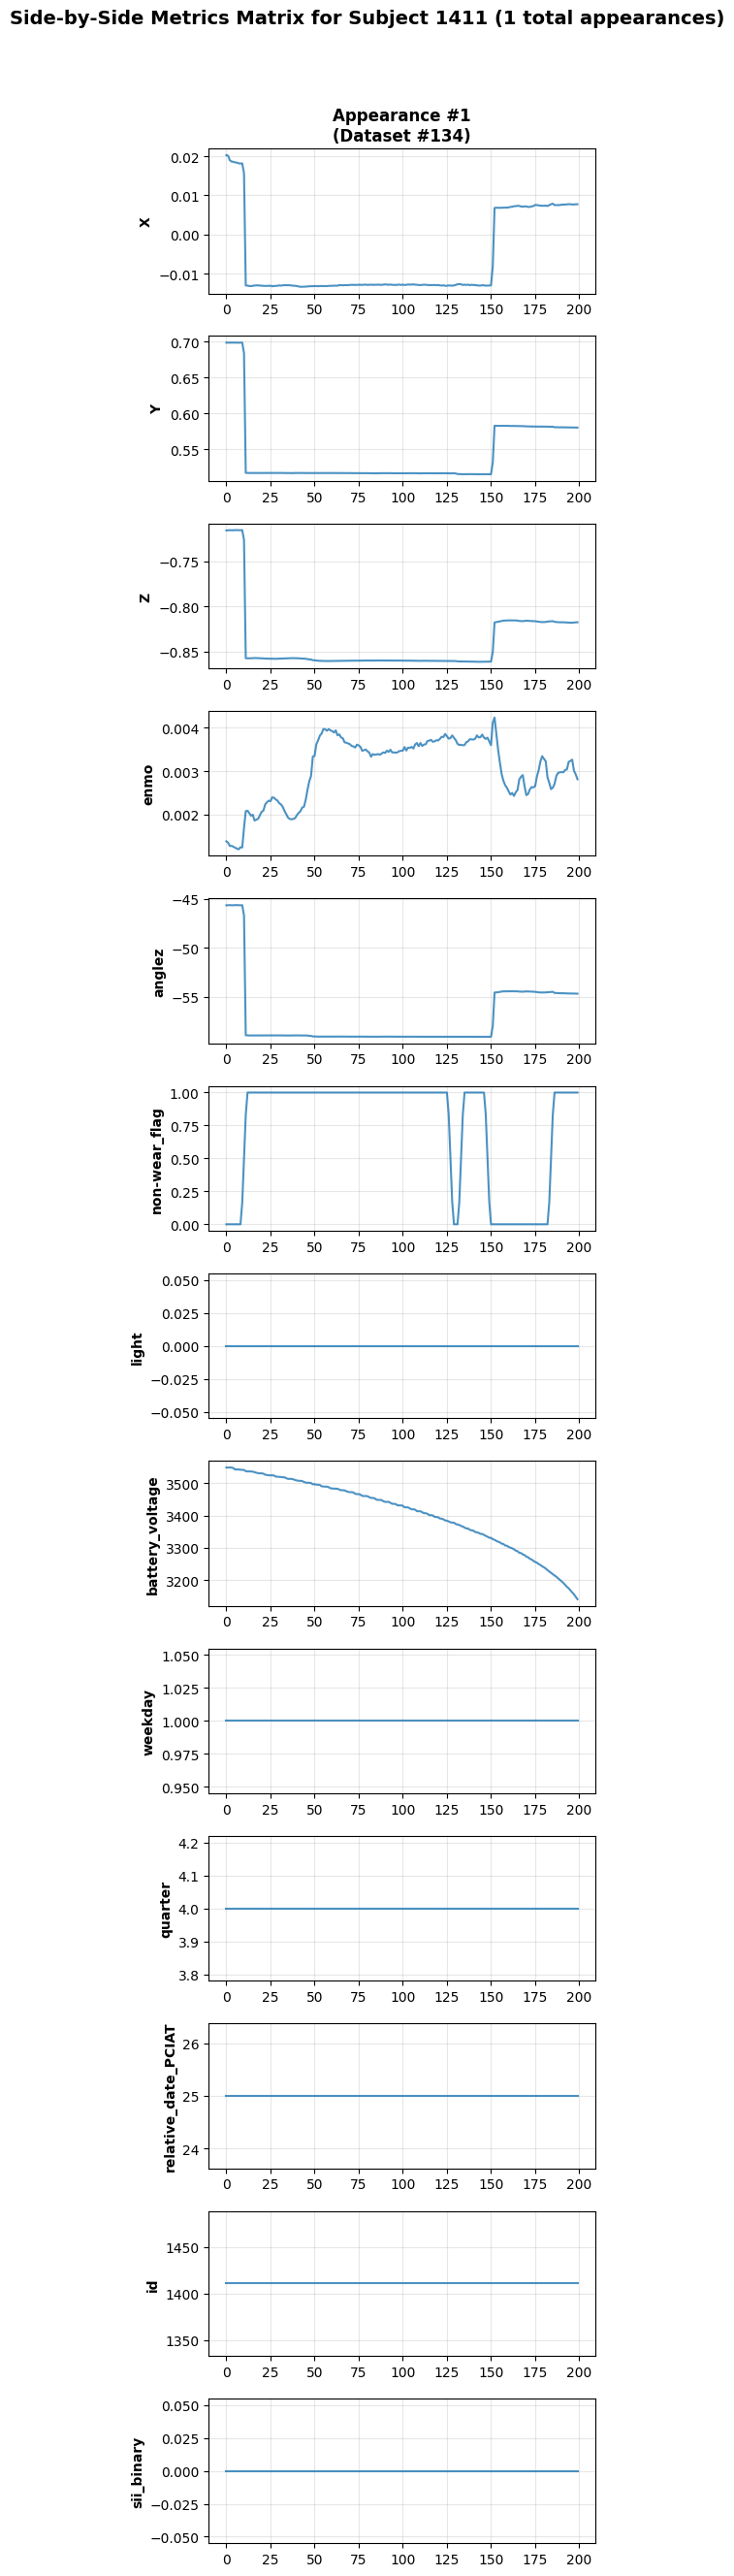

In [25]:
plot_subject_dashboard(CMI_timeseries_dataset, target_id="1411", dataset_idx=None)

# SELECTION


In [26]:
import numpy as np
kept_data, removed_data = [], []

for df in CMI_timeseries_dataset:
    if df["non-wear_flag"].mean() <= 0.5:
        kept_data.append(df)
    else:
        removed_data.append(df)

# Output summary metrics
print(f"Original: {len(CMI_timeseries_dataset)}")
print(f"Kept: {len(kept_data)} (always wear + mostly wear)")
print(f"Removed: {len(removed_data)} (mostly non-wear)")



Original: 4437
Kept: 4307 (always wear + mostly wear)
Removed: 130 (mostly non-wear)


In [27]:
# Compute distributions directly from the lists
orig_prob = sum(df["sii_binary"].iloc[0] for df in CMI_timeseries_dataset)
filt_prob = sum(df["sii_binary"].iloc[0] for df in kept_data)

print(f"\nProblematic: {orig_prob} → {filt_prob}")
print(
    f"Non-problematic: {len(CMI_timeseries_dataset)-orig_prob} → {len(kept_data)-filt_prob}"
)


Problematic: 1480 → 1420
Non-problematic: 2957 → 2887


In [28]:
analysis = []
for i, df in enumerate(CMI_timeseries_dataset):
    vals = df["non-wear_flag"].values
    mean_val = vals.mean()  # Fraction of time spent in non-wear state (1)

    # Only process subjects with actual varying patterns (contains both 0 and 1)
    if 0 < mean_val < 1:
        pct_wear = (1 - mean_val) * 100
        analysis.append(
            {
                "dataframe_idx": i,
                "id": df["id"].iloc[0],
                "sii_binary": df["sii_binary"].iloc[0],
                "class": (
                    "Problematic"
                    if df["sii_binary"].iloc[0] == 1
                    else "Non-problematic"
                ),
                "percent_wearing": pct_wear,
                "percent_non_wear": mean_val * 100,
                "transitions": np.sum(np.diff(vals) != 0),
                "dominant_state": 0 if pct_wear > 50 else 1,
                "dominant_label": (
                    "Mostly Wearing" if pct_wear > 50 else "Mostly Non-wear"
                ),
            }
        )

varying_df = pd.DataFrame(analysis)
total = len(varying_df)


In [29]:
print(f"Found {total} varying wear subjects\n\nSUMMARY\n")
# 1. High-level state distributions
m_wear = (varying_df["dominant_state"] == 0).sum()
print(f"Mostly Wearing: {m_wear} subjects ({m_wear/total*100:.1f}%)")
print(
    f"Mostly Non-wear: {total - m_wear} subjects ({(total - m_wear)/total*100:.1f}%)"
)

Found 162 varying wear subjects

SUMMARY

Mostly Wearing: 49 subjects (30.2%)
Mostly Non-wear: 113 subjects (69.8%)


In [30]:
print(
    f"\nStats:\n  Avg Wear: {varying_df['percent_wearing'].mean():.1f}%"
    f"\n  Median Wear: {varying_df['percent_wearing'].median():.1f}%"
    f"\n  Avg Transitions: {varying_df['transitions'].mean():.1f} (Min: {varying_df['transitions'].min()}, Max: {varying_df['transitions'].max()})"
)


Stats:
  Avg Wear: 36.3%
  Median Wear: 29.0%
  Avg Transitions: 16.8 (Min: 4, Max: 44)


In [31]:
print(
    f"\nMOSTLY NON-WEAR (>50%):\n{varying_df[varying_df['dominant_state'] == 1][['id', 'class', 'percent_non_wear', 'transitions']].to_string(index=False)}"
)
print(
    f"\nMOSTLY WEARING (>50%):\n{varying_df[varying_df['dominant_state'] == 0][['id', 'class', 'percent_wearing', 'transitions']].head(20).to_string(index=False)}"
)


MOSTLY NON-WEAR (>50%):
  id           class  percent_non_wear  transitions
  51     Problematic         95.499998           15
3847     Problematic         81.999999           15
1411 Non-problematic         73.745835           20
 881 Non-problematic         91.084725           14
 463     Problematic         96.669447           16
3520 Non-problematic         64.254165           27
1099 Non-problematic         92.500001           15
2251 Non-problematic         61.000001           32
2848 Non-problematic         84.254164            4
 198 Non-problematic         65.499997           31
2953 Non-problematic         98.500001            7
 789 Non-problematic         86.500001           36
1855     Problematic         88.000000           23
 606 Non-problematic         75.999999           32
 599 Non-problematic         78.254163           12
2779 Non-problematic         96.754164           11
 132 Non-problematic         71.499997           15
1657 Non-problematic         94.000000 

In [32]:
always_wear, mostly_wear = [], []
always_non_wear, mostly_non_wear = [], []
total = len(CMI_timeseries_dataset)

for df in CMI_timeseries_dataset:
    vals = df["non-wear_flag"].values
    non_wear_mean = vals.mean()  # Fraction of time spent not wearing device
    
    # Check if constant (either 0.0 or 1.0 exactly)
    is_constant = non_wear_mean == 0 or non_wear_mean == 1

    if non_wear_mean <= 0.5:  # Wear time >= 50% (KEEP)
        always_wear.append(df) if is_constant else mostly_wear.append(df)
    else:                     # Wear time < 50%  (DROP)
        always_non_wear.append(df) if is_constant else mostly_non_wear.append(df)

# Construct final subset and tracking aggregates
CMI_timeseries_filtered = always_wear + mostly_wear
n_keep, n_drop = len(CMI_timeseries_filtered), total - len(CMI_timeseries_filtered)

print(f"Dataset Composition (Total: {total})")
print(f"KEEP: Always wear: {len(always_wear)} | Mostly wear: {len(mostly_wear)} | Total: {n_keep} ({n_keep/total*100:.1f}%)")
print(f"DROP: Always non-wear: {len(always_non_wear)} | Mostly non-wear: {len(mostly_non_wear)} | Total: {n_drop} ({n_drop/total*100:.1f}%)")
print(f"Created filtered dataset with {n_keep} time series")

# Vectorized Class Distribution Checks
orig_prob = sum(df["sii_binary"].iloc[0] for df in CMI_timeseries_dataset)
filt_prob = sum(df["sii_binary"].iloc[0] for df in CMI_timeseries_filtered)
print(f"Class Distribution (Problematic):\n  Original: {orig_prob} ({orig_prob/total*100:.1f}%)\n  Filtered: {filt_prob} ({filt_prob/n_keep*100:.1f}%)")

# Compressed Storage dump
print(f" NEW DATA: CMI_timeseries_filtered")

Dataset Composition (Total: 4437)
KEEP: Always wear: 4258 | Mostly wear: 49 | Total: 4307 (97.1%)
DROP: Always non-wear: 17 | Mostly non-wear: 113 | Total: 130 (2.9%)
Created filtered dataset with 4307 time series
Class Distribution (Problematic):
  Original: 1480 (33.4%)
  Filtered: 1420 (33.0%)
 NEW DATA: CMI_timeseries_filtered


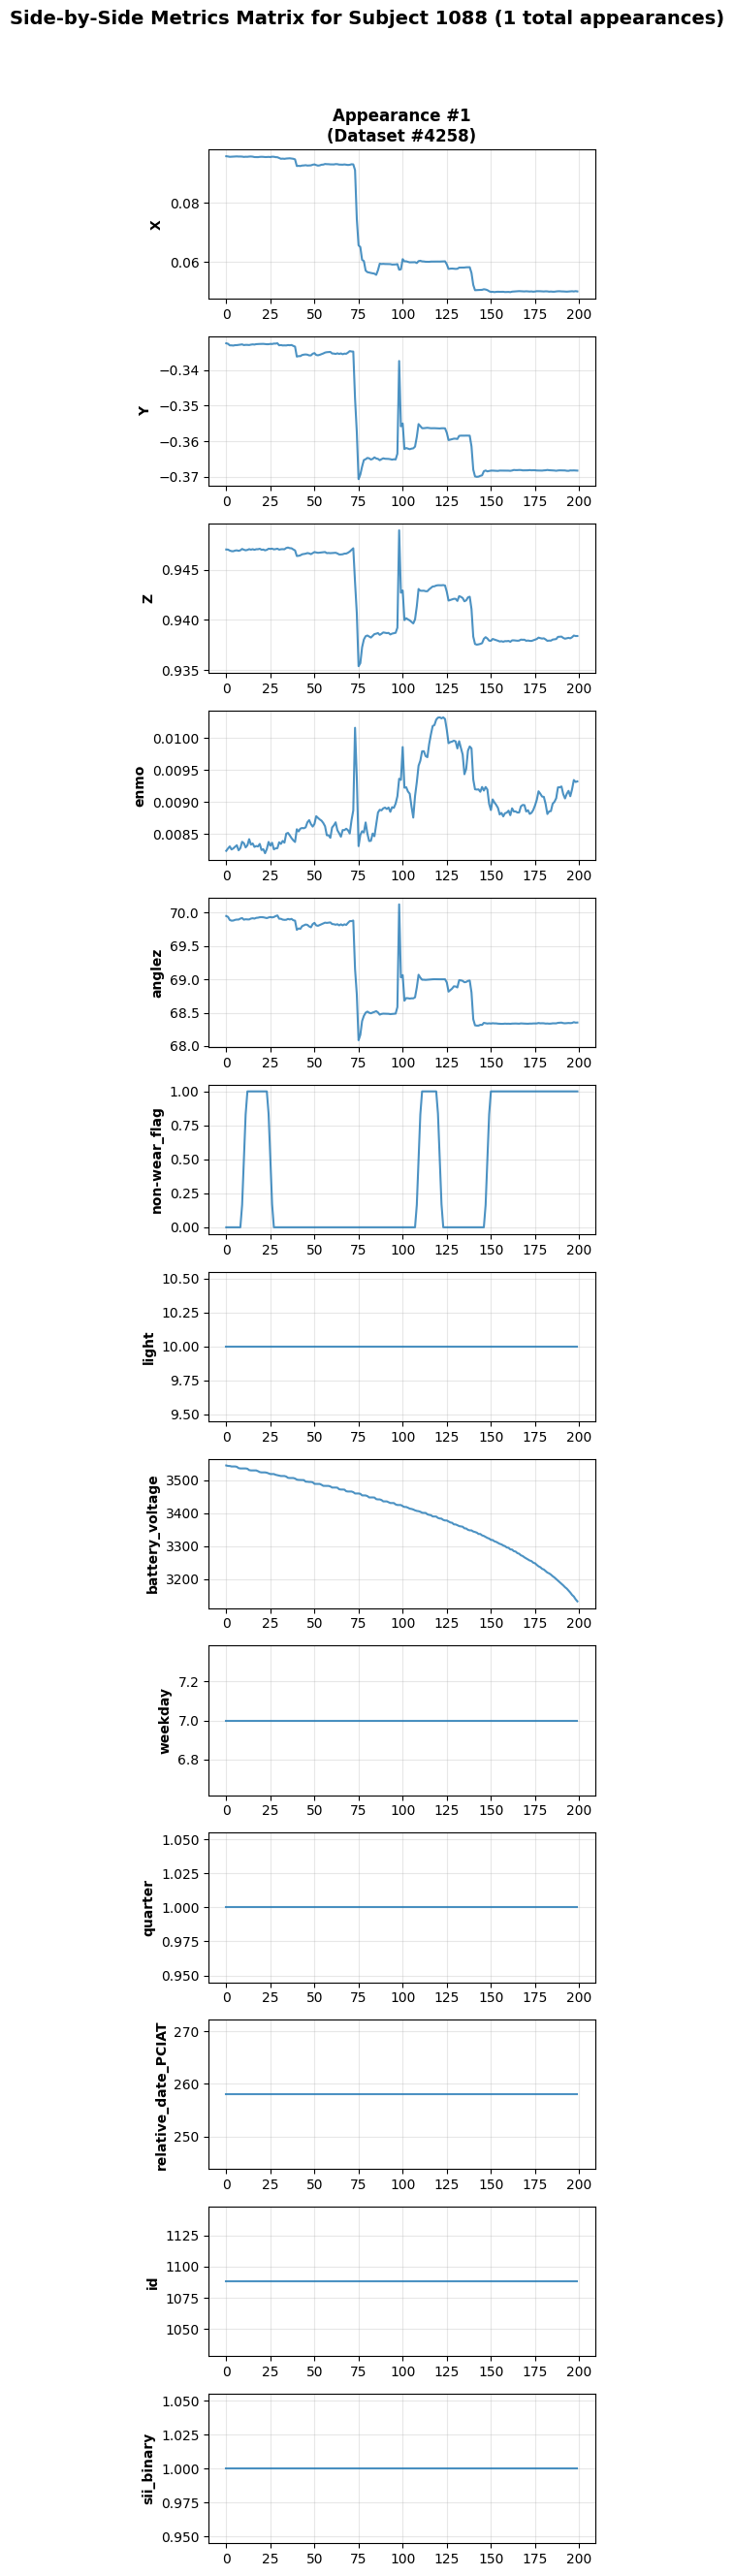

In [33]:
plot_subject_dashboard(CMI_timeseries_filtered, target_id="1088", dataset_idx=None)

## TRANSFORM NULL VALUES 

In [34]:
# Automatically detect available sensor columns (excluding metadata)
exclude = ["id", "sii_binary", "weekday", "quarter", "non-wear_flag"]
sensor_cols = [col for col in CMI_timeseries_filtered[0].columns if col not in exclude]

# Inline conversion using list comprehension and DataFrame assignment method
for df in CMI_timeseries_filtered:
    df.loc[df["non-wear_flag"] == 1, sensor_cols] = np.nan

print(f"Converted non-wear periods to NaN across {len(CMI_timeseries_filtered)} time series.")

Converted non-wear periods to NaN across 4307 time series.


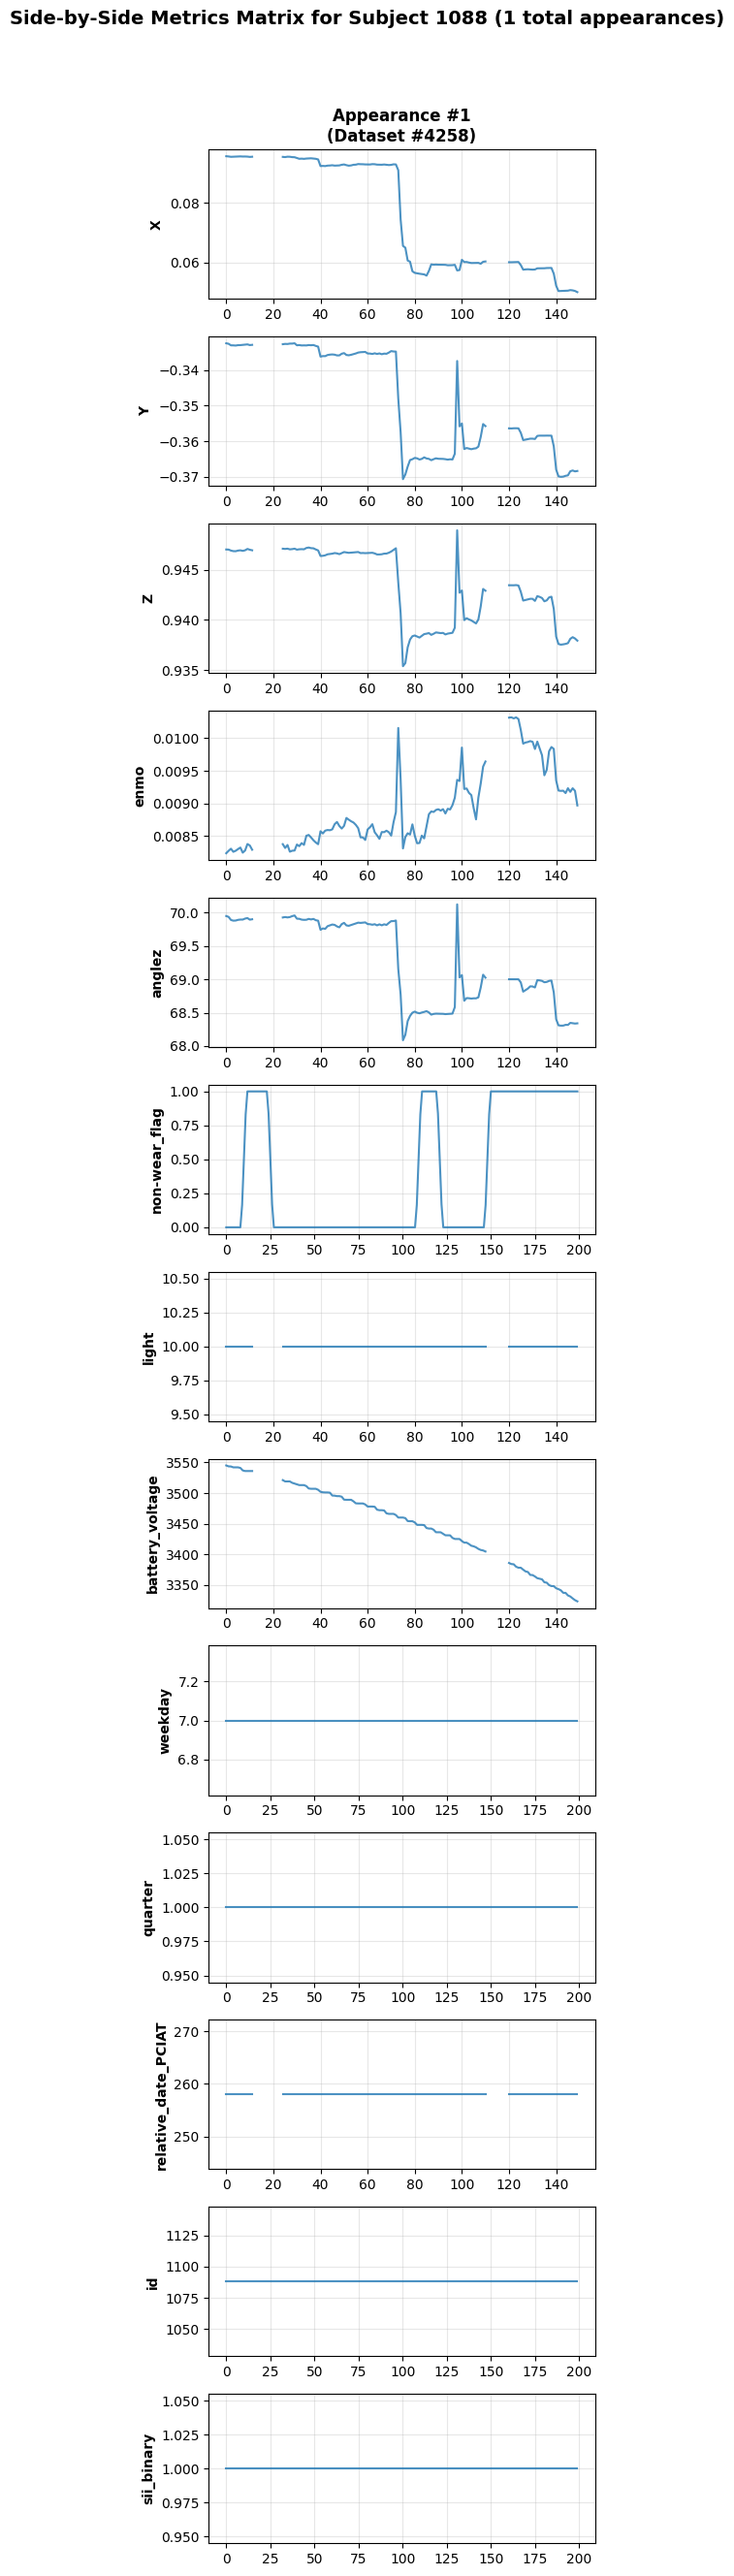

In [35]:
plot_subject_dashboard(CMI_timeseries_filtered, target_id="1088", dataset_idx=None)

## INTERPOLATION

In [36]:

for df in CMI_timeseries_filtered:
    df[sensor_cols] = df[sensor_cols].interpolate(
        method="linear", limit_direction="both"
    )

print(
    f"Successfully interpolated missing values across {len(CMI_timeseries_filtered)} time series."
)



Successfully interpolated missing values across 4307 time series.


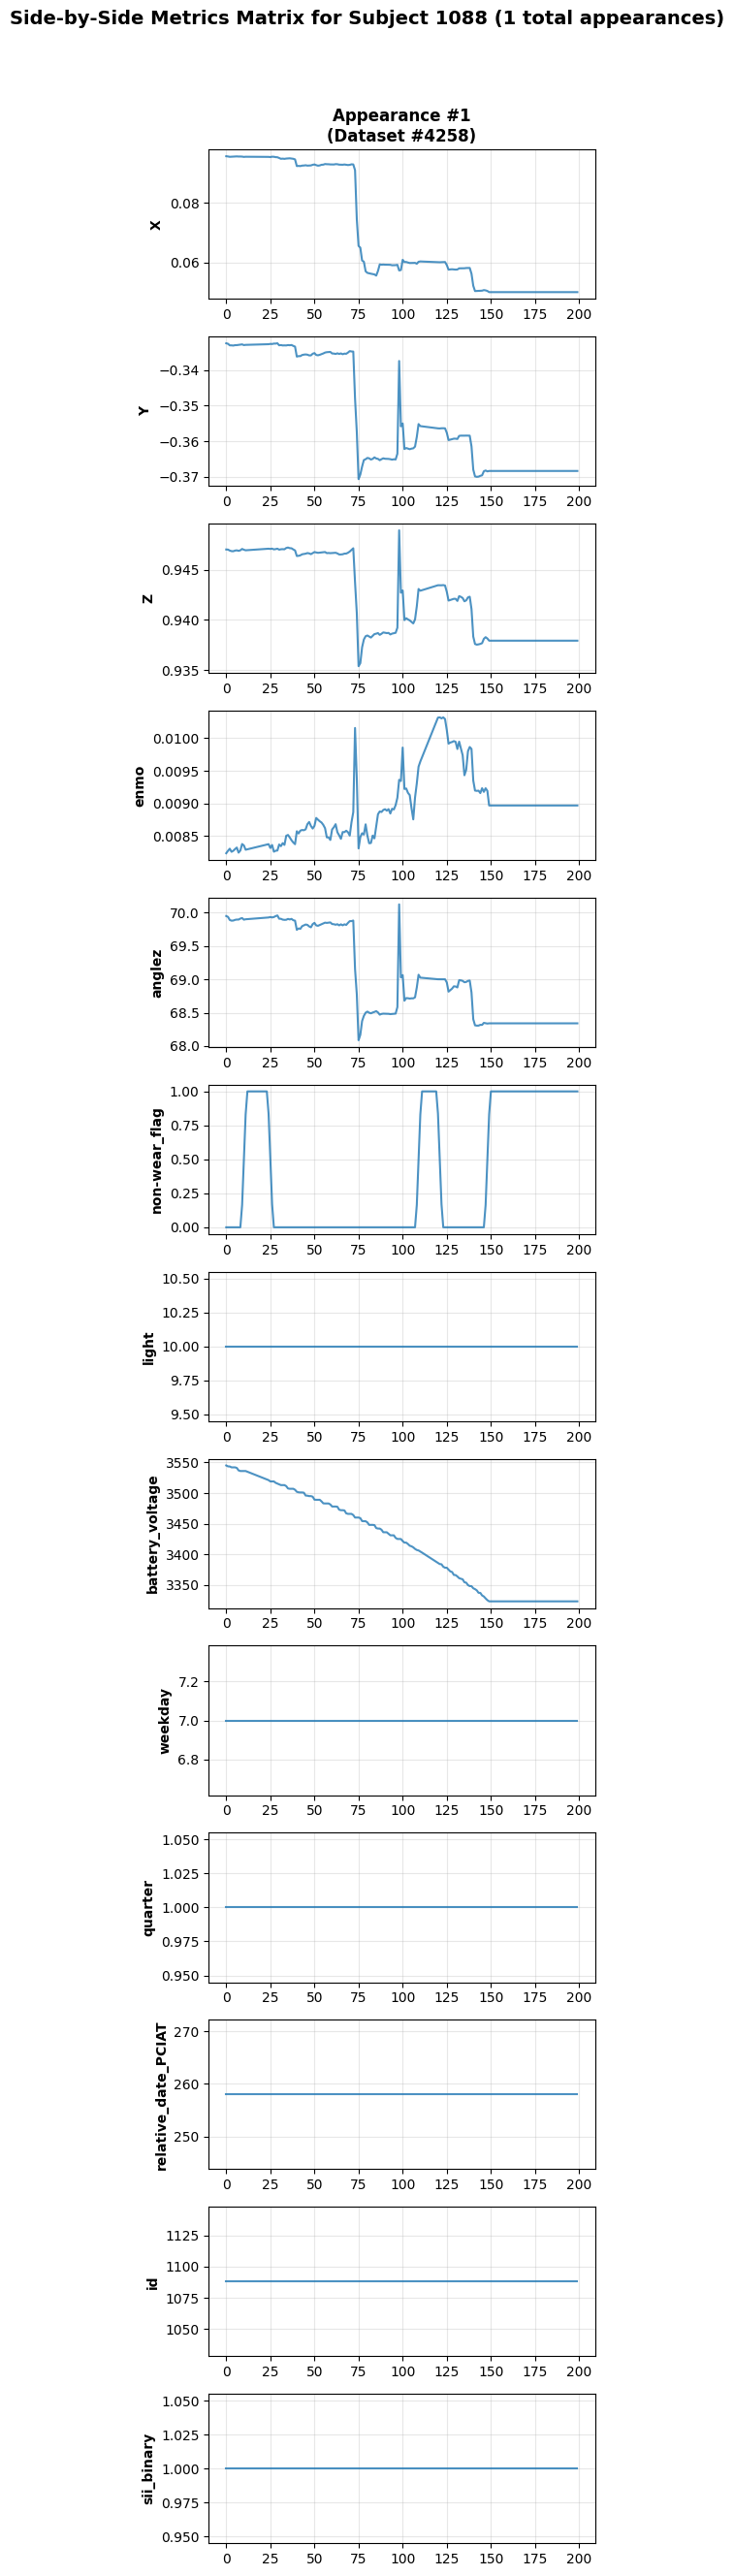

In [37]:
plot_subject_dashboard(CMI_timeseries_filtered, target_id="1088", dataset_idx=None)

# NORMALIZATION

## LOAD THE INTERPOLATED/CLEAN DATA

In [48]:
# Save
with gzip.open("../1.DATASET/CMI_timeseries_clean.pkl.gz", "wb") as f:
    pickle.dump(CMI_timeseries_filtered, f)

print(f"Saved: CMI_timeseries_clean.pkl.gz")

Saved: CMI_timeseries_clean.pkl.gz


In [ ]:
# Check how many subjects/time series
with gzip.open("../1.DATASET/CMI_timeseries_clean.pkl.gz", "rb") as f:
	
	 data = pickle.load(f)
print(f"Number of time series: {len(data)}")
total_subjects = len(data) 

Number of time series: 4307


In [55]:
signals = [
    "enmo",
    "anglez",
    "light",
    "X",
    "Y",
    "Z",
    "battery_voltage",
    "relative_date_PCIAT",
]
results = {}

## PARAMETERS

In [56]:
N_PERMUTATIONS = 20  # Kept lower so your individual loop runs fast
SEASONALITY_LAG = 48  # 24-hour cycle
HETERO_WINDOW = 48  # 24-hour window for variance
ADF_ALPHA = 0.01
KPSS_ALPHA = 0.05
LEVENE_ALPHA = 0.05

## SEASONALITY THRESHOLD GENERATOR

In [57]:
def get_local_acf_threshold(ts, lag, n_perm=N_PERMUTATIONS):
    n_elements = len(ts)
    if n_elements <= lag:
        return 0.0
    rng = np.random.default_rng()
    shuffled_indices = [rng.permutation(n_elements) for _ in range(n_perm)]
    surrogate_corrs = [
        abs(np.corrcoef(ts[idxs][:-lag], ts[idxs][lag:])[0, 1])
        for idxs in shuffled_indices
    ]
    clean_corrs = [c for c in surrogate_corrs if not np.isnan(c)]
    return np.percentile(clean_corrs, 95) if clean_corrs else 0.0

## DIAGNOSTIC PASS

In [59]:
CMI_timeseries_personalized = []
# Track transformation counts globally just for your final insight
total_transforms_applied = {"log1p": 0, "detrend": 0, "deseasonal": 0}

for i, df in enumerate(data):
    df_clean = df.copy()
    subject_id = df_clean["id"].iloc[0]

    # Progress tracking indicator
    if (i + 1) % 50 == 0 or (i + 1) == total_subjects:
        sys.stdout.write(
            f"\r Prrc: {i + 1}/{total_subjects} subjects..."
        )
        sys.stdout.flush()

    for signal in signals:
        if signal not in df_clean.columns:
            continue

        y = df_clean[signal].values
        n_samples = len(y)

        # Skip logic if data is completely flat or empty
        if n_samples < SEASONALITY_LAG + 10 or np.ptp(y) == 0:
            continue

        # ── STEP 1: LIVE INDIVIDUAL DIAGNOSIS ────────────────────────────────
        # We test this specific vector right now to see what it needs
        
        # Check Heteroscedasticity (Does THIS subject need variance stabilization?)
        n_blocks = n_samples // HETERO_WINDOW
        need_log1p = False
        if n_blocks >= 3:
            blocks = np.reshape(
                y[: n_blocks * HETERO_WINDOW], (n_blocks, HETERO_WINDOW)
            )
            _, levene_p = levene(*blocks, center="median")
            need_log1p = levene_p < LEVENE_ALPHA

        # Check Trend (Does THIS subject have a linear drift?)
        try:
            adf_p = adfuller(y, autolag="AIC")[1]
            kpss_p = kpss(y, regression="c", nlags="auto")[1]
            need_detrend = (adf_p > ADF_ALPHA) and (kpss_p < KPSS_ALPHA)
        except:
            need_detrend = False

        # Check Seasonality (Is THIS subject experiencing a 24h periodic wave?)
        try:
            real_corr = np.corrcoef(y[:-SEASONALITY_LAG], y[SEASONALITY_LAG:])[
                0, 1
            ]
            threshold = get_local_acf_threshold(y, SEASONALITY_LAG)
            need_deseasonal = abs(real_corr) > threshold
        except:
            need_deseasonal = False

        # ── STEP 2: LIVE INDIVIDUAL TREATMENT ────────────────────────────────
        # Apply the changes purely based on the local booleans calculated above
        
        if need_log1p:
            y = np.log1p(np.maximum(0, y))
            total_transforms_applied["log1p"] += 1

        if need_detrend:
            x = np.arange(len(y))
            slope, intercept = np.polyfit(x, y, 1)
            y = y - (slope * x + intercept)
            total_transforms_applied["detrend"] += 1

        if need_deseasonal:
            try:
                res = STL(y, period=48, robust=True).fit()
                y = y - res.seasonal
                total_transforms_applied["deseasonal"] += 1
            except:
                pass

        # Every signal still gets a final scaling so the dimensions match for the ML model
        scaler = RobustScaler()
        df_clean[signal] = scaler.fit_transform(y.reshape(-1, 1)).flatten()

    CMI_timeseries_personalized.append(df_clean)

print("\n\nSUCCESS: All data customized individually.")
print(f"Total Custom log1p applied: {total_transforms_applied['log1p']}")
print(f"Total Custom Detrends applied: {total_transforms_applied['detrend']}")
print(
    f"Total Custom Deseasonalizations applied: {total_transforms_applied['deseasonal']}"
)

 Prrc: 1250/4307 subjects...

c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


 Prrc: 2750/4307 subjects...

c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


 Prrc: 3850/4307 subjects...

c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


 Prrc: 4307/4307 subjects...

SUCCESS: All data customized individually.
Total Custom log1p applied: 25385
Total Custom Detrends applied: 8073
Total Custom Deseasonalizations applied: 11312


In [60]:
output_filename = "CMI_timeseries_personalized.pkl.gz"
print(f"\nSaving {output_filename}...")

with gzip.open(output_filename, "wb") as f:
    pickle.dump(CMI_timeseries_personalized, f)



Saving CMI_timeseries_personalized.pkl.gz...


## GENERATE SUMMARY VOTES

In [44]:
print(f"\n{'=' * 70}\nFINAL DIAGNOSTIC REPORT CARD (n = {total_to_process})\n{'=' * 70}")
print(f"{'Signal Name':<20} {'Trend %':>12} {'Seasonal %':>12} {'Hetero %':>12}")
print("-" * 62)

global_transform_rules = {}

for signal in signals:
    valid_records = [r[signal] for r in results.values() if signal in r]
    n = len(valid_records)

    trend_pct = sum(r["trend"] for r in valid_records) / n
    season_pct = sum(r["seasonal"] for r in valid_records) / n
    hetero_pct = sum(r["heteroscedastic"] for r in valid_records) / n

    print(
        f"{signal:<20} "
        f"{trend_pct*100:10.1f}% "
        f"{season_pct*100:10.1f}% "
        f"{hetero_pct*100:10.1f}%"
    )

    # Save decisions: If more than 50% of the files show this problem, flag it for a cure!
    global_transform_rules[signal] = {
        "log1p": hetero_pct >= 0.5,
        "detrend": trend_pct >= 0.5,
        "deseasonal": season_pct >= 0.5,
    }


FINAL DIAGNOSTIC REPORT CARD (n = 500)
Signal Name               Trend %   Seasonal %     Hetero %
--------------------------------------------------------------
enmo                       23.5%       26.0%       87.3%
anglez                     13.2%       25.5%       92.2%
light                      12.3%       25.0%       91.7%
X                          28.9%       27.0%       88.7%
Y                           6.9%       22.5%       55.9%
Z                          13.2%       21.6%       90.2%
battery_voltage            99.5%       98.5%       87.3%
relative_date_PCIAT         0.0%        0.0%        0.0%


In [45]:
global_transform_rules

{'enmo': {'log1p': True, 'detrend': False, 'deseasonal': False},
 'anglez': {'log1p': True, 'detrend': False, 'deseasonal': False},
 'light': {'log1p': True, 'detrend': False, 'deseasonal': False},
 'X': {'log1p': True, 'detrend': False, 'deseasonal': False},
 'Y': {'log1p': True, 'detrend': False, 'deseasonal': False},
 'Z': {'log1p': True, 'detrend': False, 'deseasonal': False},
 'battery_voltage': {'log1p': True, 'detrend': True, 'deseasonal': True},
 'relative_date_PCIAT': {'log1p': False,
  'detrend': False,
  'deseasonal': False}}

##  NORMALIZATION

In [46]:
from sklearn.preprocessing import RobustScaler
from statsmodels.tsa.seasonal import STL

print(f"\n{'='*70}\nEXECUTING TREATMENT ENGINE ON SIGNALS\n{'='*70}")

final_transformed_dataset = []

# Loop through every single dataframe in your data array
for idx, df in enumerate(data):
    df_clean = df.copy()
    subject_id = df_clean["id"].iloc[0]

    for signal in signals:
        if signal not in df_clean.columns:
            continue

        y = df_clean[signal].values

        # If data is completely flat or missing, don't break it, just scale it
        if np.isnan(y).any() or np.ptp(y) == 0:
            continue

        # Fetch what rules Phase 1 voted on for this signal
        rules = global_transform_rules.get(
            signal, {"log1p": False, "detrend": False, "deseasonal": False}
        )

        # Treatment A: Fix Heteroscedasticity using Variance Stabilization
        if rules["log1p"]:
            y = np.log1p(np.maximum(0, y))

        # Treatment B: Fix Linear Trends using OLS Detrending Residuals
        if rules["detrend"]:
            x = np.arange(len(y))
            slope, intercept = np.polyfit(x, y, 1)
            y = y - (slope * x + intercept)

        # Treatment C: Fix Seasonality using STL Seasonal Subtraction
        if rules["deseasonal"]:
            try:
                # 48 steps = 24 hours. Strip out seasonal variations cleanly
                res = STL(y, period=48, robust=True).fit()
                y = y - res.seasonal
            except:
                pass  # Keep current vector if time-series format is anomalous

        # Final Uniform Polish: Bring to a unified zero-centered scale
        scaler = RobustScaler()
        df_clean[signal] = scaler.fit_transform(y.reshape(-1, 1)).flatten()


    final_transformed_dataset.append(df_clean)

print(
    f"SUCCESS: All {len(final_transformed_dataset)} datasets completely normalized!"
)


EXECUTING TREATMENT ENGINE ON SIGNALS
SUCCESS: All 4307 datasets completely normalized!


In [41]:
def permutation_acf_threshold(ts, lag, n_perm=N_PERMUTATIONS):
    n_elements = len(ts)
    if n_elements <= lag:
        return 0.0
    rng = np.random.default_rng()
    shuffled_indices = [rng.permutation(n_elements) for _ in range(n_perm)]
    surrogate_corrs = [
        abs(np.corrcoef(ts[idxs][:-lag], ts[idxs][lag:])[0, 1])
        for idxs in shuffled_indices
    ]
    return np.percentile([c for c in surrogate_corrs if not np.isnan(c)], 95)

In [42]:
subset_data = data[:N_SUBJECTS]
total_to_process = len(subset_data)

for i, df in enumerate(subset_data):
    subject_id = df["id"].iloc[0]

    # CRITICAL FIX: Always instantiate the subject dictionary
    results[subject_id] = {}

    if (i + 1) % 50 == 0 or (i + 1) == total_to_process:
        sys.stdout.write(
            f"Processing Progress: {i + 1}/{total_to_process} subjects..."
        )
        sys.stdout.flush()

    for signal in signals:
        # Default assignment ensures this signal is counted in final denominator
        results[subject_id][signal] = DEFAULT_FLAGS.copy()

        ts = df[signal].dropna().values
        n_samples = len(ts)

        # Skip tests if data doesn't permit it, but keep the False defaults!
        if n_samples < SEASONALITY_LAG + 10 or np.ptp(ts) == 0:
            continue

        # ── 1. TREND TEST ────────────────────────────────────────────────────
        try:
            adf_p = adfuller(ts, autolag="AIC")[1]
            kpss_p = kpss(ts, regression="c", nlags="auto")[1]
            has_trend = (adf_p > ADF_ALPHA) and (kpss_p < KPSS_ALPHA)
        except:
            has_trend = False

        # ── 2. SEASONALITY TEST ───────────────────────────────────────────────
        try:
            real_corr = np.corrcoef(ts[:-SEASONALITY_LAG], ts[SEASONALITY_LAG:])[
                0, 1
            ]
            threshold = permutation_acf_threshold(ts, SEASONALITY_LAG)
            has_seasonality = abs(real_corr) > threshold
        except:
            has_seasonality = False

        # ── 3. HETEROSCEDASTICITY TEST ────────────────────────────────────────
        n_blocks = n_samples // HETERO_WINDOW
        if n_blocks >= 3:
            blocks = np.reshape(
                ts[: n_blocks * HETERO_WINDOW], (n_blocks, HETERO_WINDOW)
            )
            _, levene_p = levene(*blocks, center="median")
            has_hetero = levene_p < LEVENE_ALPHA
        else:
            has_hetero = False

        # Overwrite defaults with actual test flags
        results[subject_id][signal] = {
            "trend": has_trend,
            "seasonal": has_seasonality,
            "heteroscedastic": has_hetero,
        }

print("\n\n Profile analysis complete.")

C:\Users\paula\AppData\Local\Temp\ipykernel_11988\3145213365.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(ts, regression="c", nlags="auto")[1]
C:\Users\paula\AppData\Local\Temp\ipykernel_11988\3145213365.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(ts, regression="c", nlags="auto")[1]
C:\Users\paula\AppData\Local\Temp\ipykernel_11988\3145213365.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(ts, regression="c", nlags="auto")[1]
C:\Users\paula\AppData\Local\Temp\ipykernel_11988\3145213365.py:30: InterpolationWarning: The test statistic is outside of the range of 

Processing Progress: 50/500 subjects...

C:\Users\paula\AppData\Local\Temp\ipykernel_11988\3145213365.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(ts, regression="c", nlags="auto")[1]
C:\Users\paula\AppData\Local\Temp\ipykernel_11988\3145213365.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(ts, regression="c", nlags="auto")[1]
C:\Users\paula\AppData\Local\Temp\ipykernel_11988\3145213365.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(ts, regression="c", nlags="auto")[1]
C:\Users\paula\AppData\Local\Temp\ipykernel_11988\3145213365.py:30: InterpolationWarning: The test statistic is outside of the range of 

Processing Progress: 100/500 subjects...

C:\Users\paula\AppData\Local\Temp\ipykernel_11988\3145213365.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(ts, regression="c", nlags="auto")[1]
C:\Users\paula\AppData\Local\Temp\ipykernel_11988\3145213365.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(ts, regression="c", nlags="auto")[1]
C:\Users\paula\AppData\Local\Temp\ipykernel_11988\3145213365.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(ts, regression="c", nlags="auto")[1]
C:\Users\paula\AppData\Local\Temp\ipykernel_11988\3145213365.py:30: InterpolationWarning: The test statistic is outside of the range of 

...

Processing Progress: 450/500 subjects...

C:\Users\paula\AppData\Local\Temp\ipykernel_11988\3145213365.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(ts, regression="c", nlags="auto")[1]
C:\Users\paula\AppData\Local\Temp\ipykernel_11988\3145213365.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(ts, regression="c", nlags="auto")[1]
C:\Users\paula\AppData\Local\Temp\ipykernel_11988\3145213365.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(ts, regression="c", nlags="auto")[1]
C:\Users\paula\AppData\Local\Temp\ipykernel_11988\3145213365.py:30: InterpolationWarning: The test statistic is outside of the range of 

Processing Progress: 500/500 subjects...

C:\Users\paula\AppData\Local\Temp\ipykernel_11988\3145213365.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(ts, regression="c", nlags="auto")[1]
C:\Users\paula\AppData\Local\Temp\ipykernel_11988\3145213365.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(ts, regression="c", nlags="auto")[1]
C:\Users\paula\AppData\Local\Temp\ipykernel_11988\3145213365.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(ts, regression="c", nlags="auto")[1]
C:\Users\paula\AppData\Local\Temp\ipykernel_11988\3145213365.py:30: InterpolationWarning: The test statistic is outside of the range of 



 Profile analysis complete.


In [ ]:
print(f"\n{'=' * 65}\nCORRECTED SUMMARY (n = {total_to_process})\n{'=' * 65}")
print(f"{'Signal':<10} {'Trend':>12} {'Seasonal':>12} {'Heterosc.':>12}\n{'-' * 50}")

In [277]:
print(f"\nSUMMARY — proportion of subjects flagged per signal\n")
print(f"{'Signal':<10} {'Trend':>12} {'Seasonal':>12} {'Heterosc.':>12}\n{'-' * 50}")

for signal in signals:
    valid_r = [r[signal] for r in results.values() if signal in r]
    n = len(valid_r)

    if n == 0:
        continue

    t_cnt = sum(r["trend"] for r in valid_r)
    s_cnt = sum(r["seasonal"] for r in valid_r)
    h_cnt = sum(r["heteroscedastic"] for r in valid_r)

    print(
        f"{signal:<10} "
        f"{t_cnt}/{n} ({t_cnt/n*100:4.0f}%)   "
        f"{s_cnt}/{n} ({s_cnt/n*100:4.0f}%)   "
        f"{h_cnt}/{n} ({h_cnt/n*100:4.0f}%)"
    )


SUMMARY — proportion of subjects flagged per signal

Signal            Trend     Seasonal    Heterosc.
--------------------------------------------------
enmo       55/249 (  22%)   52/249 (  21%)   219/249 (  88%)
anglez     29/249 (  12%)   56/249 (  22%)   225/249 (  90%)
light      35/249 (  14%)   58/249 (  23%)   227/249 (  91%)
X          62/249 (  25%)   76/249 (  31%)   229/249 (  92%)
Y          15/249 (   6%)   61/249 (  24%)   134/249 (  54%)
Z          27/249 (  11%)   62/249 (  25%)   224/249 (  90%)
battery_voltage 246/249 (  99%)   245/249 (  98%)   225/249 (  90%)
relative_date_PCIAT 0/249 (   0%)   0/249 (   0%)   0/249 (   0%)


In [278]:
for signal in signals:
    valid_r = [r[signal] for r in results.values() if signal in r]
    n = len(valid_r)

    if n == 0:
        continue

    t_pct = sum(r["trend"] for r in valid_r) / n
    s_pct = sum(r["seasonal"] for r in valid_r) / n
    h_pct = sum(r["heteroscedastic"] for r in valid_r) / n

    recs = []
    if h_pct >= 0.5:
        recs.append("log1p (variance stabilisation)")
    if t_pct >= 0.5:
        recs.append("detrend per subject (OLS residuals)")
    if s_pct >= 0.5:
        recs.append("STL decomposition → work on residuals")
    if not recs:
        recs.append("RobustScaler only")

    print(
        f"\n  {signal.upper()}  (trend={t_pct*100:.0f}%, seasonal={s_pct*100:.0f}%, hetero={h_pct*100:.0f}%)"
    )
    for r in recs:
        print(f"    → {r}")


  ENMO  (trend=22%, seasonal=21%, hetero=88%)
    → log1p (variance stabilisation)

  ANGLEZ  (trend=12%, seasonal=22%, hetero=90%)
    → log1p (variance stabilisation)

  LIGHT  (trend=14%, seasonal=23%, hetero=91%)
    → log1p (variance stabilisation)

  X  (trend=25%, seasonal=31%, hetero=92%)
    → log1p (variance stabilisation)

  Y  (trend=6%, seasonal=24%, hetero=54%)
    → log1p (variance stabilisation)

  Z  (trend=11%, seasonal=25%, hetero=90%)
    → log1p (variance stabilisation)

  BATTERY_VOLTAGE  (trend=99%, seasonal=98%, hetero=90%)
    → log1p (variance stabilisation)
    → detrend per subject (OLS residuals)
    → STL decomposition → work on residuals

  RELATIVE_DATE_PCIAT  (trend=0%, seasonal=0%, hetero=0%)
    → RobustScaler only


# EXTRA 

In [160]:
import gzip
import pickle
import numpy as np
from scipy import stats
from scipy.stats import levene
from statsmodels.tsa.stattools import adfuller, kpss

# ── CONFIG ────────────────────────────────────────────────────────────────────

N_SUBJECTS       = 4304       # subjects to diagnose (increase for full run)
N_PERMUTATIONS   = 1000     # surrogate shuffles for seasonality threshold
SEASONALITY_LAG  = 48       # lag 48 = 24h assuming 30-min bins; adjust if needed
HETERO_WINDOW    = 48       # window size for Levene test blocks (48 = 24h)
ADF_ALPHA        = 0.01     # stricter than 0.05 — long series are hypersensitive
KPSS_ALPHA       = 0.05     # standard
LEVENE_ALPHA     = 0.05     # standard
SURROGATE_PCTILE = 95       # percentile of null distribution for seasonality

# ── LOAD DATA ─────────────────────────────────────────────────────────────────

with gzip.open("../1.DATASET/CMI_timeseries_clean.pkl.gz", "rb") as f:
    data = pickle.load(f)

signals = ['enmo', 'anglez', 'light','X','Y','Z','battery_voltage','relative_date_PCIAT']
results = {}

# ── HELPER: permutation threshold for autocorrelation ────────────────────────

def permutation_acf_threshold(ts, lag, n_perm=N_PERMUTATIONS, pctile=SURROGATE_PCTILE):
    """
    Build a null distribution of autocorrelations at `lag` by randomly
    shuffling the series. Returns the pctile-th percentile as the threshold.
    A real autocorrelation above this is unlikely to be random noise.
    """
    surrogate_corrs = []
    for _ in range(n_perm):
        shuffled = np.random.permutation(ts)
        if len(shuffled) > lag:
            c = np.corrcoef(shuffled[:-lag], shuffled[lag:])[0, 1]
            surrogate_corrs.append(abs(c))
    return np.percentile(surrogate_corrs, pctile)

# ── MAIN LOOP ─────────────────────────────────────────────────────────────────

print("=" * 65)
print("ANALYZING TIME SERIES PROPERTIES (principled thresholds)")
print("=" * 65)

for i, df in enumerate(data[:N_SUBJECTS]):
    subject_id = df['id'].iloc[0]
    results[subject_id] = {}

    print(f"\nSubject {subject_id}  ({len(df)} timesteps):")

    for signal in signals:
        ts = df[signal].dropna().values

        # ── 0. DEFENSIVE CHECKS (Length & Constancy) ──────────────────────────
        if len(ts) < SEASONALITY_LAG + 10:
            print(f"  {signal}: series too short — skipping")
            continue

        # Check if the series is completely flat (variance = 0)
        if np.ptp(ts) == 0:
            print(f"  {signal}: series is CONSTANT (all values {ts[0]}) — skipping tests")
            
            # Populate safe defaults to prevent downstream dictionary KeyErrors
            results[subject_id][signal] = {
                'trend':            False,
                'seasonal':         False,
                'heteroscedastic':  False,
                'adf_pvalue':       1.0,
                'kpss_pvalue':      1.0,
                'acf_real':         0.0,
                'acf_threshold':    0.0,
                'levene_p':         1.0,
                'levene_stat':      0.0,
            }
            continue

        # ── 1. TREND TEST (ADF + KPSS) ───────────────────────────────────────
        # ADF  null: series HAS a unit root (non-stationary)
        #      p > ADF_ALPHA  → fail to reject → trend present
        # KPSS null: series IS stationary
        #      p < KPSS_ALPHA → reject stationarity → trend present
        # Both must agree (AND) to flag a trend — reduces false positives.
        # ADF_ALPHA = 0.01 (not 0.05) because long series make ADF hyper-
        # sensitive; a tiny drift gets flagged as significant at 0.05.

        adf_pvalue  = adfuller(ts, autolag='AIC')[1]
        kpss_pvalue = kpss(ts, regression='c', nlags='auto')[1]
        has_trend   = (adf_pvalue > ADF_ALPHA) and (kpss_pvalue < KPSS_ALPHA)

        # Carry continuous values for interpretability
        trend_strength = adf_pvalue   # higher → stronger evidence of trend

        # ── 2. SEASONALITY TEST (permutation-based) ───────────────────────────
        # Instead of hardcoded 0.3, we build a null distribution by shuffling
        # the series (destroying temporal order but keeping marginal distribution).
        # The 95th percentile of surrogate |correlations| is our data-driven
        # threshold — anything above it is genuinely periodic, not noise.

        try:
            real_corr  = np.corrcoef(ts[:-SEASONALITY_LAG],
                                     ts[SEASONALITY_LAG:])[0, 1]
            threshold  = permutation_acf_threshold(ts, SEASONALITY_LAG)
            has_seasonality   = abs(real_corr) > threshold
            seasonal_strength = abs(real_corr)   # continuous score
        except Exception:
            has_seasonality   = False
            seasonal_strength = 0.0
            threshold         = 0.0

        # ── 3. HETEROSCEDASTICITY (Levene test) ───────────────────────────────
        # Split series into non-overlapping blocks of HETERO_WINDOW timesteps.
        # Levene's test checks whether those blocks have equal variance.
        # null hypothesis: all blocks have equal variance.
        # p < LEVENE_ALPHA → reject → variance is NOT constant → heteroscedastic.
        # This replaces the arbitrary CV > 0.3 heuristic with a test that has
        # a known false-positive rate.

        blocks = [ts[j:j + HETERO_WINDOW]
                  for j in range(0, len(ts) - HETERO_WINDOW, HETERO_WINDOW)
                  if len(ts[j:j + HETERO_WINDOW]) == HETERO_WINDOW]

        if len(blocks) >= 3:
            levene_stat, levene_p = levene(*blocks, center='median')
            has_hetero    = levene_p < LEVENE_ALPHA
            hetero_strength = levene_stat   # larger → stronger heteroscedasticity
        else:
            has_hetero      = False
            hetero_strength = 0.0
            levene_p        = 1.0

        # ── STORE ─────────────────────────────────────────────────────────────

        results[subject_id][signal] = {
            # binary flags
            'trend':            has_trend,
            'seasonal':         has_seasonality,
            'heteroscedastic':  has_hetero,
            # continuous diagnostic values
            'adf_pvalue':        round(adf_pvalue,  4),
            'kpss_pvalue':       round(kpss_pvalue, 4),
            'acf_real':          round(seasonal_strength, 4),
            'acf_threshold':     round(threshold,   4),
            'levene_p':          round(levene_p,    4),
            'levene_stat':       round(hetero_strength, 2),
        }

        # ── PRINT ─────────────────────────────────────────────────────────────

        print(
            f"  {signal:<8} "
            f"trend={str(has_trend):<5}  "
            f"(ADF p={adf_pvalue:.4f} α={ADF_ALPHA}, "
            f"KPSS p={kpss_pvalue:.4f} α={KPSS_ALPHA})  |  "
            f"seasonal={str(has_seasonality):<5}  "
            f"(ACF={seasonal_strength:.3f} > perm_thr={threshold:.3f})  |  "
            f"hetero={str(has_hetero):<5}  "
            f"(Levene p={levene_p:.4f} α={LEVENE_ALPHA})"
        )

# ── SUMMARY ───────────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print("SUMMARY — proportion of subjects flagged per signal")
print("=" * 65)
print(f"{'Signal':<10} {'Trend':>12} {'Seasonal':>12} {'Heterosc.':>12}")
print("-" * 50)

for signal in signals:
    n             = len(results)
    trend_count   = sum(r[signal]['trend']           for r in results.values() if signal in r)
    season_count  = sum(r[signal]['seasonal']        for r in results.values() if signal in r)
    hetero_count  = sum(r[signal]['heteroscedastic'] for r in results.values() if signal in r)

    print(
        f"{signal:<10} "
        f"{trend_count}/{n} ({trend_count/n*100:4.0f}%)   "
        f"{season_count}/{n} ({season_count/n*100:4.0f}%)   "
        f"{hetero_count}/{n} ({hetero_count/n*100:4.0f}%)"
    )

# ── TRANSFORM RECOMMENDATIONS ─────────────────────────────────────────────────

print("\n" + "=" * 65)
print("TRANSFORM RECOMMENDATIONS (majority vote across subjects)")
print("=" * 65)

for signal in signals:
    n            = len([r for r in results.values() if signal in r])
    trend_pct    = sum(r[signal]['trend']           for r in results.values() if signal in r) / n
    season_pct   = sum(r[signal]['seasonal']        for r in results.values() if signal in r) / n
    hetero_pct   = sum(r[signal]['heteroscedastic'] for r in results.values() if signal in r) / n

    recs = []
    if hetero_pct  >= 0.5: recs.append("log1p (variance stabilisation)")
    if trend_pct   >= 0.5: recs.append("detrend per subject (OLS residuals)")
    if season_pct  >= 0.5: recs.append("STL decomposition → work on residuals")
    if not recs:           recs.append("RobustScaler only")

    print(f"\n  {signal.upper()}  "
          f"(trend={trend_pct*100:.0f}%, seasonal={season_pct*100:.0f}%, "
          f"hetero={hetero_pct*100:.0f}%)")
    for r in recs:
        print(f"    → {r}")


ANALYZING TIME SERIES PROPERTIES (principled thresholds)

Subject 2265  (200 timesteps):
  enmo     trend=False  (ADF p=0.0000 α=0.01, KPSS p=0.1000 α=0.05)  |  seasonal=True   (ACF=0.147 > perm_thr=0.140)  |  hetero=True   (Levene p=0.0001 α=0.05)
  anglez   trend=False  (ADF p=0.2562 α=0.01, KPSS p=0.0798 α=0.05)  |  seasonal=True   (ACF=0.163 > perm_thr=0.158)  |  hetero=True   (Levene p=0.0013 α=0.05)
  light    trend=False  (ADF p=0.0000 α=0.01, KPSS p=0.1000 α=0.05)  |  seasonal=False  (ACF=0.024 > perm_thr=0.140)  |  hetero=True   (Levene p=0.0086 α=0.05)
  X        trend=False  (ADF p=0.1826 α=0.01, KPSS p=0.0924 α=0.05)  |  seasonal=True   (ACF=0.195 > perm_thr=0.164)  |  hetero=True   (Levene p=0.0000 α=0.05)
  Y        trend=False  (ADF p=0.0001 α=0.01, KPSS p=0.1000 α=0.05)  |  seasonal=True   (ACF=0.212 > perm_thr=0.165)  |  hetero=False  (Levene p=0.1970 α=0.05)
  Z        trend=False  (ADF p=0.0000 α=0.01, KPSS p=0.0830 α=0.05)  |  seasonal=True   (ACF=0.160 > perm_thr=0

In [161]:
import gzip
import pickle
import numpy as np
import pandas as pd
import warnings
from scipy import stats
from scipy.signal import periodogram
from sklearn.preprocessing import RobustScaler
from statsmodels.tsa.seasonal import STL
from statsmodels.tools.sm_exceptions import InterpolationWarning

# =============================================================================
# PER-SIGNAL CORRECTION PIPELINE
# Driven by diagnostic results (majority vote across 200 subjects):
#
#   ENMO             hetero=85%  → log1p → RobustScaler
#   ANGLEZ           hetero=86%  → RobustScaler only  ← no log1p (has negatives)
#   LIGHT            hetero=89%  → log1p → RobustScaler
#   X                hetero=91%  → RobustScaler only  ← no log1p (has negatives)
#   Y                hetero=58%  → RobustScaler only  ← no log1p (has negatives)
#   Z                hetero=87%  → RobustScaler only  ← no log1p (has negatives)
#   BATTERY_VOLTAGE  trend=98%, seasonal=96%, hetero=87%
#                              → detrend (OLS) → STL residuals → MinMaxScaler
#   RELATIVE_DATE_PCIAT  all 0% → per-subject z-score (no other transforms)
# =============================================================================

# ── CONFIG ────────────────────────────────────────────────────────────────────

NON_WEAR_THR   = 0.5
STL_PERIOD     = 48    # 48 timesteps = 24h assuming 30-min bins — adjust if needed
MIN_STL_LENGTH = STL_PERIOD * 2 + 1   # minimum series length for STL

# ── LOAD DATA ─────────────────────────────────────────────────────────────────

with gzip.open("../1.DATASET/CMI_timeseries_clean.pkl.gz", "rb") as f:
    data = pickle.load(f)

print("=" * 65)
print("PER-SIGNAL CORRECTION PIPELINE")
print("=" * 65)
print(f"  Subjects loaded : {len(data)}")

# =============================================================================
# STEP 1 — FIT GLOBAL SCALERS ON WORN DATA ONLY
# Scalers must see only real human movement, not non-wear noise.
# We pool worn-time values across ALL subjects before fitting.
# =============================================================================

print("\nSTEP 1 — Collecting worn-time values for global scaler fitting...")

# Signals and whether they need log1p before scaling
SCALE_CONFIG = {
    'enmo':   {'log1p': True,  'scaler': 'robust'},
    'anglez': {'log1p': False, 'scaler': 'robust'},
    'light':  {'log1p': True,  'scaler': 'robust'},
    'X':      {'log1p': False, 'scaler': 'robust'},
    'Y':      {'log1p': False, 'scaler': 'robust'},
    'Z':      {'log1p': False, 'scaler': 'robust'},
}

# battery_voltage and relative_date_PCIAT are handled per-subject (see steps 3/4)

fit_values = {col: [] for col in SCALE_CONFIG}

for df in data:
    worn = df[df['non-wear_flag'] < NON_WEAR_THR]
    for col, cfg in SCALE_CONFIG.items():
        if col not in worn.columns:
            continue
        vals = worn[col].dropna().values
        if cfg['log1p']:
            vals = np.log1p(np.clip(vals, 0, None))
        fit_values[col].extend(vals)

# Fit one RobustScaler per signal using quantile range 5-95
# (wider than default 25-75 to handle the extreme movement spikes)
scalers = {}
for col, cfg in SCALE_CONFIG.items():
    arr = np.array(fit_values[col]).reshape(-1, 1)
    scaler = RobustScaler(quantile_range=(5, 95))
    scaler.fit(arr)
    scalers[col] = scaler
    print(f"  RobustScaler [{col}]  "
          f"center={scaler.center_[0]:.4f}  scale={scaler.scale_[0]:.4f}"
          f"{'  (fitted on log1p values)' if cfg['log1p'] else ''}")

# =============================================================================
# STEP 2 — APPLY TRANSFORMS PER SUBJECT
# =============================================================================

print("\nSTEP 2 — Applying per-signal corrections to all subjects...")

corrected_data = []
skipped_counts = {col: 0 for col in list(SCALE_CONFIG.keys()) + ['battery_voltage']}

for i, df in enumerate(data):
    ndf          = df.copy().reset_index(drop=True)
    non_wear_mask = ndf['non-wear_flag'] >= NON_WEAR_THR
    worn_idx      = ~non_wear_mask

    # ── 2a. ENMO and LIGHT: log1p → RobustScaler ─────────────────────────────
    # log1p compresses the right tail (both are non-negative and right-skewed).
    # RobustScaler then centres and scales using the IQR — robust to activity spikes.

    for col in ['enmo', 'light']:
        if col not in ndf.columns:
            continue
        vals = ndf[col].values.astype(float)
        vals = np.log1p(np.clip(vals, 0, None))          # log1p (safe for ≥0)
        vals = scalers[col].transform(vals.reshape(-1, 1)).flatten()
        vals[non_wear_mask] = np.nan                      # mask non-worn AFTER scaling
        ndf[col] = vals

    # ── 2b. ANGLEZ, X, Y, Z: RobustScaler only ───────────────────────────────
    # These signals are symmetric around zero — log1p would distort negatives.
    # RobustScaler handles their heteroscedasticity (high activity variance)
    # by using IQR instead of std, which is robust to movement spikes.

    for col in ['anglez', 'X', 'Y', 'Z']:
        if col not in ndf.columns:
            continue
        vals = ndf[col].values.astype(float)
        vals = scalers[col].transform(vals.reshape(-1, 1)).flatten()
        vals[non_wear_mask] = np.nan
        ndf[col] = vals

    # ── 2c. BATTERY_VOLTAGE: OLS detrend → STL residuals → MinMax [0,1] ──────
    # Diagnostic result: trend=98%, seasonal=96% (charge cycles).
    # Strategy:
    #   1. OLS detrend — removes the slow long-term voltage drift
    #   2. STL decomposition — separates the charge/discharge cycle (seasonal)
    #      from the residual (true battery state signal)
    #   3. Scale residuals to [0,1] so downstream models see normalised state

    if 'battery_voltage' in ndf.columns:
        bv = ndf['battery_voltage'].values.astype(float)
        t  = np.arange(len(bv))

        # OLS detrend
        slope, intercept, *_ = stats.linregress(t, bv)
        bv_detrended = bv - (intercept + slope * t)

        # STL decomposition (only if series long enough)
        if len(bv_detrended) >= MIN_STL_LENGTH:
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    stl    = STL(bv_detrended, period=STL_PERIOD, robust=True)
                    result = stl.fit()
                bv_residual = result.resid
            except Exception:
                bv_residual = bv_detrended   # fallback to detrended only
                skipped_counts['battery_voltage'] += 1
        else:
            bv_residual = bv_detrended
            skipped_counts['battery_voltage'] += 1

        # MinMax to [0, 1] — applied locally per subject because charge range
        # varies by device and recording length
        bv_min, bv_max = bv_residual.min(), bv_residual.max()
        if bv_max > bv_min:
            bv_scaled = (bv_residual - bv_min) / (bv_max - bv_min)
        else:
            bv_scaled = np.zeros_like(bv_residual)   # constant → map to 0

        ndf['battery_voltage'] = bv_scaled

    # ── 2d. RELATIVE_DATE_PCIAT: per-subject z-score ──────────────────────────
    # Diagnostic result: trend=0%, seasonal=0%, hetero=0% — already stationary.
    # The absolute date value is meaningless for classification; what matters is
    # how each measurement sits within that subject's own assessment window.
    # Per-subject z-score removes the between-subject offset while preserving
    # within-subject temporal structure.

    if 'relative_date_PCIAT' in ndf.columns:
        worn_vals = ndf.loc[worn_idx, 'relative_date_PCIAT'].dropna()
        if len(worn_vals) > 1:
            mu    = worn_vals.mean()
            sigma = worn_vals.std()
            sigma = sigma if sigma > 0 else 1.0
            ndf['relative_date_PCIAT'] = (ndf['relative_date_PCIAT'] - mu) / sigma

    # ── PASS-THROUGH: categorical and binary columns ──────────────────────────
    # weekday, quarter, non-wear_flag, id, sii_binary — no transformation

    corrected_data.append(ndf)

print(f"  ✅ Corrected {len(corrected_data)} subjects")
if any(v > 0 for v in skipped_counts.values()):
    print(f"  ⚠ STL fallback (series too short): {skipped_counts['battery_voltage']} subjects")

# =============================================================================
# STEP 3 — SANITY CHECKS
# Verify each transform did what it was supposed to do.
# =============================================================================

print("\nSTEP 3 — Sanity checks")
print("=" * 65)

# Pool worn-time values post-correction for verification
def pool_worn(col):
    vals = []
    for df in corrected_data:
        worn = df[df['non-wear_flag'] < NON_WEAR_THR]
        vals.extend(worn[col].dropna().values)
    return np.array(vals)

print(f"\n{'Signal':<25} {'Mean':>8} {'Median':>8} {'Std':>8} {'Min':>8} {'Max':>8}  Check")
print("-" * 75)

checks = {
    'enmo':                 ('median ≈ 0',   lambda v: abs(np.median(v)) < 0.5),
    'anglez':               ('median ≈ 0',   lambda v: abs(np.median(v)) < 0.5),
    'light':                ('median ≈ 0',   lambda v: abs(np.median(v)) < 0.5),
    'X':                    ('median ≈ 0',   lambda v: abs(np.median(v)) < 0.5),
    'Y':                    ('median ≈ 0',   lambda v: abs(np.median(v)) < 0.5),
    'Z':                    ('median ≈ 0',   lambda v: abs(np.median(v)) < 0.5),
    'battery_voltage':      ('[0,1] range',  lambda v: v.min() >= -0.01 and v.max() <= 1.01),
    'relative_date_PCIAT':  ('mean ≈ 0',     lambda v: abs(np.mean(v)) < 0.5),
}

for col, (check_label, check_fn) in checks.items():
    if col not in corrected_data[0].columns:
        continue
    v    = pool_worn(col)
    ok   = check_fn(v)
    flag = '✅' if ok else '⚠'
    print(f"  {col:<23} {np.mean(v):>8.3f} {np.median(v):>8.3f} "
          f"{np.std(v):>8.3f} {v.min():>8.3f} {v.max():>8.3f}  "
          f"{flag} {check_label}")

# Verify NaN propagation for non-wear rows
sample        = corrected_data[0]
non_wear_rows = (sample['non-wear_flag'] >= NON_WEAR_THR).sum()
nan_in_enmo   = sample['enmo'].isna().sum()
print(f"\n  Non-worn rows in subject 0 : {non_wear_rows}")
print(f"  NaN in enmo after masking  : {nan_in_enmo}  "
      f"{'✅ match' if non_wear_rows == nan_in_enmo else '⚠ mismatch'}")

# =============================================================================
# STEP 4 — SAVE
# =============================================================================

output_path = "../1.DATASET/CMI_timeseries_normalized.pkl.gz"
with gzip.open(output_path, "wb") as f:
    pickle.dump(corrected_data, f)

print(f"\n💾 Saved {len(corrected_data)} corrected DataFrames → {output_path}")
print("\n✅ Pipeline complete")

PER-SIGNAL CORRECTION PIPELINE
  Subjects loaded : 4304

STEP 1 — Collecting worn-time values for global scaler fitting...
  RobustScaler [enmo]  center=0.0315  scale=0.1765  (fitted on log1p values)
  RobustScaler [anglez]  center=-7.8054  scale=95.4848
  RobustScaler [light]  center=2.2412  scale=4.6200  (fitted on log1p values)
  RobustScaler [X]  center=-0.2387  scale=1.5745
  RobustScaler [Y]  center=0.0021  scale=1.1926
  RobustScaler [Z]  center=-0.1135  scale=1.3972

STEP 2 — Applying per-signal corrections to all subjects...


KeyboardInterrupt: 